In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ugradio
from astropy import units as u
from astropy import constants as c
from scipy.optimize import curve_fit

In [2]:
gc_on = np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/gc_1420_moremhz.npz')
gc_off = np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/gc_1419_moremhz.npz')
bb_on = np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/bb_1420_moremhz.npz')
bb_off = np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/bb_1419_moremhz.npz')
zenith_on = np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/Zenith_1420_moremhz.npz')
zenith_off= np.load('/home/radiopi/Astro-121-Radio-Stars/LAB2/Zenith_1419_moremhz.npz')

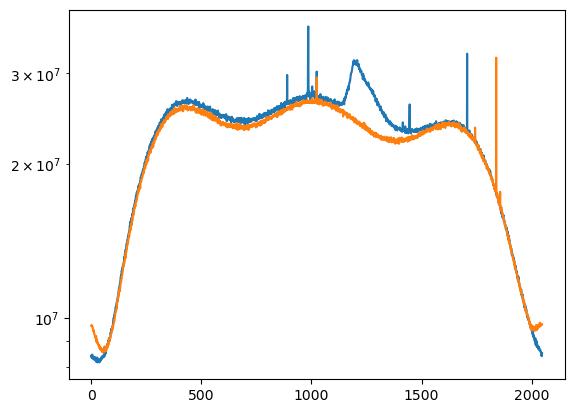

In [3]:
plt.plot(gc_on['power'])
plt.yscale('log')
plt.plot(gc_off['power'])

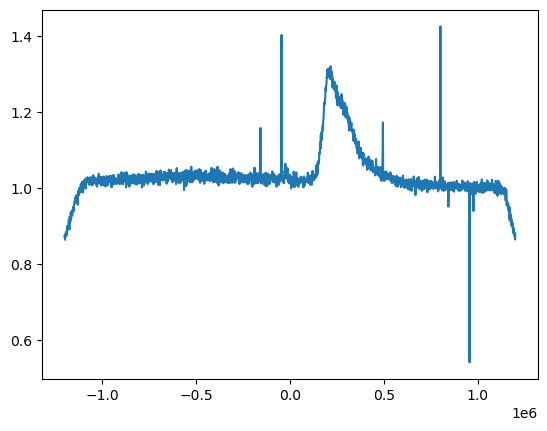

In [4]:
plt.plot(gc_on['frequencies'],gc_on['power']/gc_off['power'])

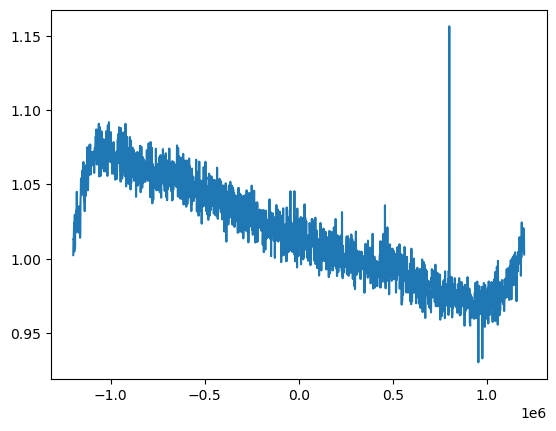

In [5]:
plt.plot(bb_on['frequencies'],bb_on['power']/bb_off['power'])

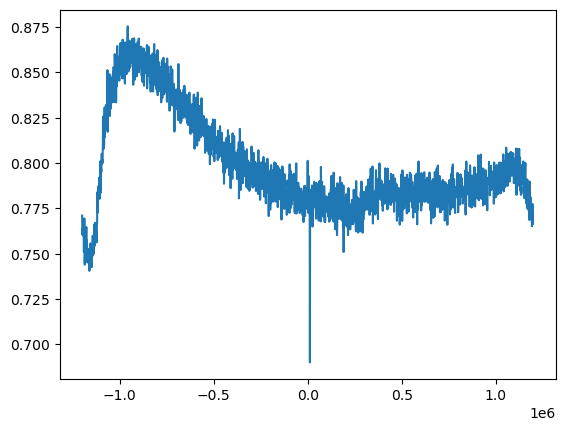

In [6]:
plt.plot(zenith_on['frequencies'],zenith_on['power']/zenith_off['power'])

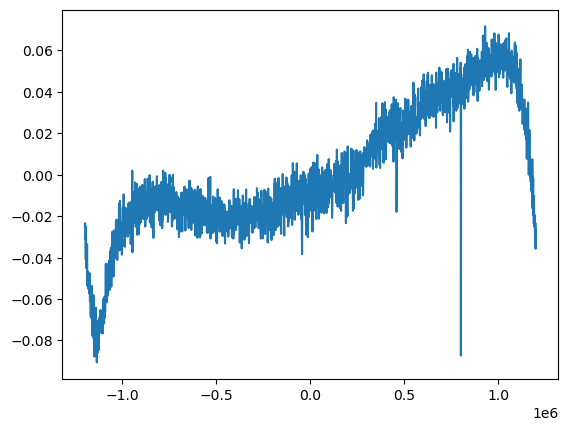

In [29]:
sky_power = zenith_on['power'] 
bb_power = bb_on['power']

s_line = sky_power/bb_power - 0.8
plt.plot(bb_on['frequencies'], s_line)

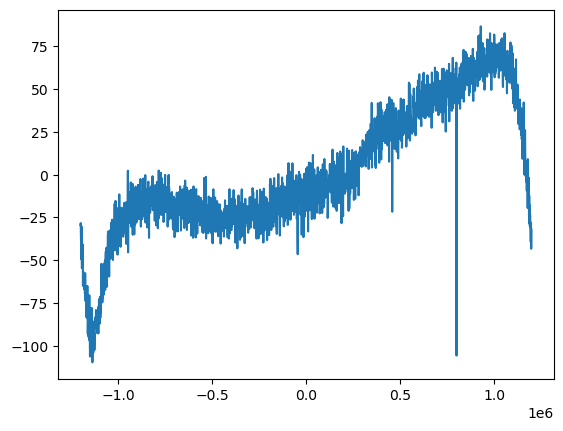

In [30]:
diff = np.sum(bb_power - sky_power)
G = 300/diff * np.sum(sky_power)
t_line = G * s_line
plt.plot(bb_on['frequencies'], t_line)


2461104.1989140958


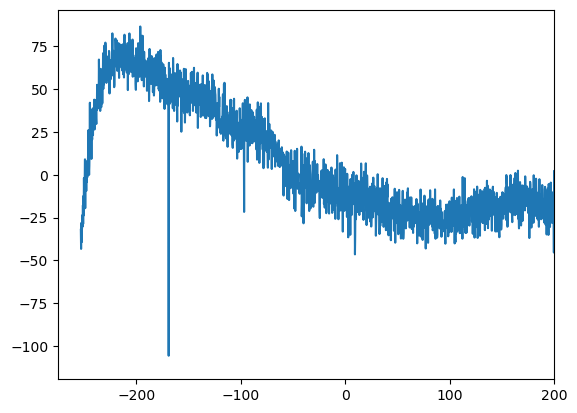

In [41]:
v = - bb_on['frequencies']/1420e6 * c.c.to(u.km/u.s)
plt.plot(v, t_line)
plt.xlim(-275,200)
jd_now = ugradio.timing.julian_date()
print(jd_now)

In [42]:
dop_v = ugradio.doppler.get_projected_velocity(32,37.87,2461104)* c.c.to(u.km/u.s)
v_corr = v+dop_v

(-40.0, 90.0)

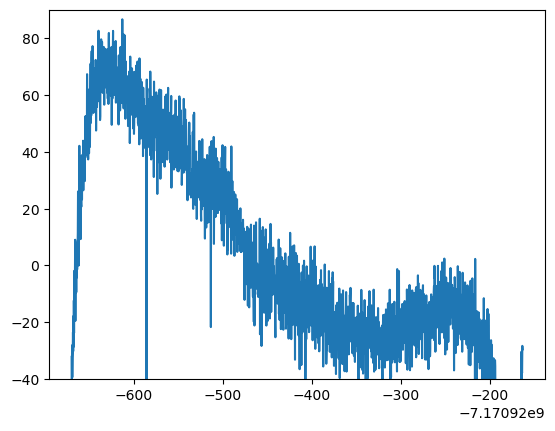

In [48]:
plt.plot(v+dop_v, t_line)
plt.ylim(-40,90)

Galactic Coordinate Spectra Analysis

Text(0.5, 1.0, 'Averaged Power Spectra')

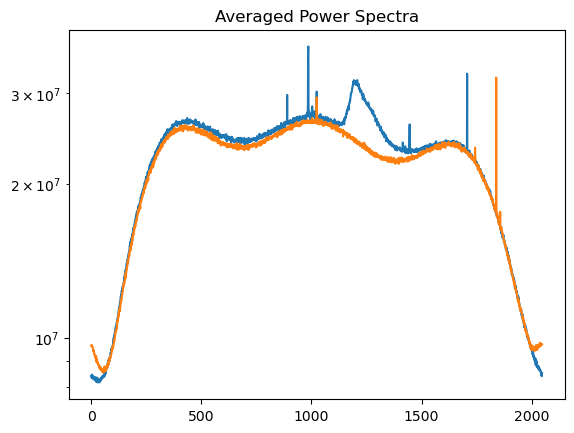

In [49]:
plt.plot(gc_on['power'])
plt.yscale('log')
plt.plot(gc_off['power'])
plt.title("Averaged Power Spectra")

Text(0.5, 1.0, 'S_line')

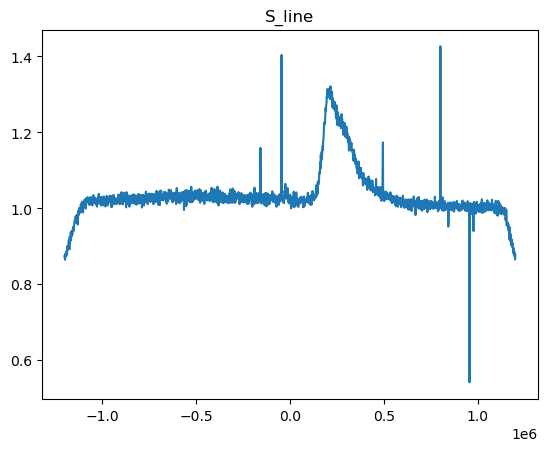

In [50]:
plt.plot(gc_on['frequencies'],gc_on['power']/gc_off['power'])
plt.title('S_line')

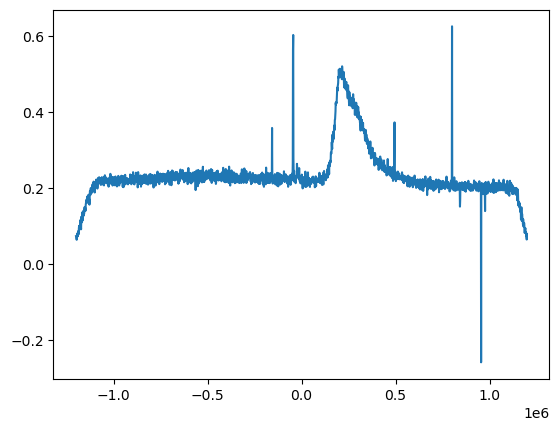

In [51]:
gc_on_power = gc_on['power'] 
gc_off_power = gc_off['power']

s_line = gc_on_power/gc_off_power - 0.8
plt.plot(bb_on['frequencies'], s_line)

Text(0.5, 1.0, 'T_line')

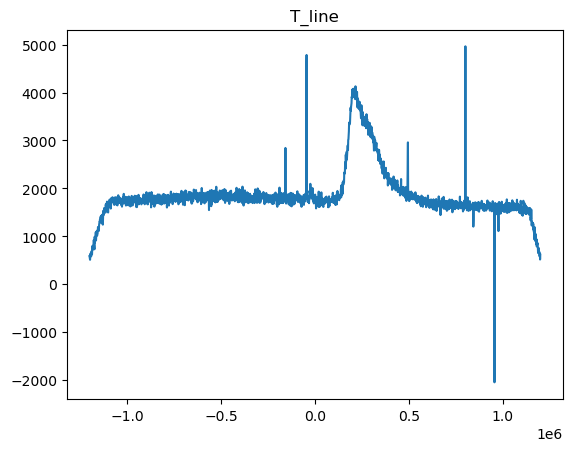

In [57]:
diff = np.sum(gc_off_power - gc_on_power)
G = 300/np.abs(diff) * np.sum(gc_on_power)
t_line = G * s_line
plt.plot(bb_on['frequencies'], t_line)
plt.title('T_line')
plt.save(fig)

2461104.240433923


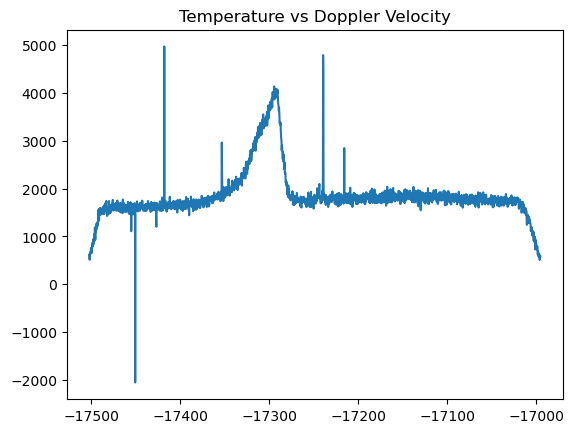

In [138]:
v = - gc_off['frequencies']/1420e6 * 3e5
dop_v = ugradio.doppler.get_projected_velocity(20.66,67.87,2461103)
v_corr = v+dop_v
plt.plot(v_corr, t_line)
plt.title('Temperature vs Doppler Velocity')
plt.savefig('tvdvgc.png')
jd_now = ugradio.timing.julian_date()
print(jd_now)

In [134]:
gaussian_fit, cov = ugradio.gauss.gaussfit(x=np.array((v+dop_v)),
                                          y = np.array((t_line)),
                                          amp = [70,30],
                                          avg = [-17300, -17290],
                                          sig = [40,60],
                                          return_cov=True)
gaussian_fit

{'amp': array([1949.49279834, 1878.03271734]),
 'avg': array([-17301.4461387 , -17237.55118247]),
 'sig': array([ 13.67802593, 342.17759203])}

In [135]:
gaussian_val= ugradio.gauss.gaussval(np.array(v+dop_v),
                                    gaussian_fit['amp'],
                                    gaussian_fit['avg'],
                                    gaussian_fit['sig'])

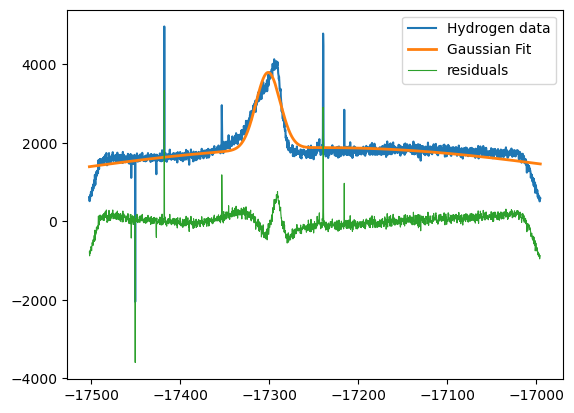

In [137]:
plt.plot(v_corr, t_line, label='Hydrogen data')
plt.plot(v_corr, gaussian_val, lw=2, label='Gaussian Fit')
plt.plot(v_corr, t_line-ugradio.gauss.gaussval(np.array(v_corr), **gaussian_fit), lw=0.8, label="residuals")
plt.legend()
plt.savefig('attemp1gf.png')